# Laboratorio 5 — Análisis de Texto
### CC3084 — Data Science | UVG | Semestre II - 2026
**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git


In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import scipy.stats as st
from wordcloud import WordCloud
from scipy.sparse import hstack
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS, CountVectorizer, TfidfVectorizer
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from nltk.corpus import opinion_lexicon


## Inciso 2. Carga de datos

In [2]:
df = pd.read_csv('train.csv')

print(df.shape)
print(df.columns.tolist())
df.head(10)

(7613, 5)
['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1


## Inciso 3. Limpieza y preprocesamiento
El preprocesamiento reduce el ruido del texto para que el modelo se enfoque en las palabras realmente informativas para distinguir desastres. 

In [3]:
def clean_text(t):
    t = t.lower()
    t = t.replace('911', ' nineoneone ')
    t = re.sub(r'http\S+|www\S+|\d+', ' ', t)
    t = re.sub(r'[^a-z\s]', ' ', t)
    t = ' '.join(w for w in t.split() if w not in ENGLISH_STOP_WORDS)
    return t

df['text_limpio'] = df['text'].apply(clean_text)
df[['text', 'text_limpio']].head(10)

,text,text_limpio
0,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake allah forgive
1,Forest fire near La Ronge Sask. Canada,forest near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent photo ruby alaska smoke wildfire...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,m hill woods
8,There's an emergency evacuation happening now ...,s emergency evacuation happening building street
9,I'm afraid that the tornado is coming to our a...,m afraid tornado coming area


Justificación:

- **Minúsculas**: unifica variantes de la misma palabra (`Fire`/`fire`) y evita tokens duplicados.
- **Quitar URLs**: no aportan información textual sobre el desastre y añaden ruido.
- **Quitar menciones `@usuario`**: el identificador no aporta contexto de clasificación.
- **Quitar símbolo `#`**: la palabra del hashtag se conserva, pero el símbolo en sí es ruido.
- **Quitar apóstrofes y puntuación**: separa partes sin significado (`'s`, comas) que no aportan al clasificador.
- **Quitar emoticonos**: son escasos y no aportan a la clasificación.
- **Quitar números**: cifras espurias (años, cantidades) no distinguen desastres. **Excepción: el `911`** se conserva (token `nineoneone`) por ser una señal clave de emergencia.
- **Quitar stopwords**: artículos, preposiciones y conjunciones (`the`, `and`, `of`) no aportan significado discriminante.

El resultado se guarda en `text_limpio`, conservando la columna original `text`.

## Inciso 4. Frecuencia de palabras por categoría

In [4]:

words_disaster = ' '.join(df[df['target'] == 1]['text_limpio']).split()
words_no_disaster = ' '.join(df[df['target'] == 0]['text_limpio']).split()

freq_disaster = Counter(words_disaster)
freq_no_disaster = Counter(words_no_disaster)

print("Top 15 palabras más frecuentes - Tweets de DESASTRE:")
for palabra, count in freq_disaster.most_common(15):
    print(f"  {palabra}: {count}")

print("\nTop 15 palabras más frecuentes - Tweets que NO son de desastre:")
for palabra, count in freq_no_disaster.most_common(15):
    print(f"  {palabra}: {count}")


Top 15 palabras más frecuentes - Tweets de DESASTRE:
  s: 408
  news: 151
  t: 150
  amp: 135
  disaster: 121
  california: 115
  suicide: 112
  police: 109
  people: 105
  m: 95
  killed: 95
  like: 94
  hiroshima: 94
  just: 89
  storm: 89

Top 15 palabras más frecuentes - Tweets que NO son de desastre:
  s: 608
  t: 365
  like: 254
  m: 242
  just: 234
  amp: 209
  new: 171
  don: 140
  body: 116
  video: 96
  people: 95
  love: 91
  time: 88
  day: 86
  know: 86


**Palabras que servirían para un mejor modelo de clasificación:**

En los tweets de desastre predominan palabras claramente temáticas y con alto poder discriminante: `disaster`, `california`, `suicide`, `killed`, `hiroshima`, `storm`, `police`. Estas palabras casi no aparecen en los tweets "normales" y por lo tanto son las que más ayudarían a un clasificador a separar ambas clases.

En los tweets que no son de desastre predominan palabras genéricas de uso cotidiano: `love`, `day`, `know`, `time`, `video`, `body` (usualmente en contextos como "body bag" en sentido figurado o cultural, no literal). Estas palabras aportan poco valor discriminante por sí solas.

También se observan tokens ruidosos como `s`, `t`, `m`, `don`, `amp` — residuos de la separación de contracciones (`it's` → `it s`, `don't` → `don t`) y de entidades HTML (`&amp;`). Esto sugiere que valdría la pena refinar aún más la limpieza (eliminar tokens de 1 letra o expandir contracciones antes de tokenizar).

**¿Vale la pena explorar bigramas o trigramas?**

Sí, definitivamente. Varias palabras sueltas son ambiguas fuera de contexto (`body`, `burning`, `storm`), pero al verlas en bigramas/trigramas el significado se vuelve mucho más claro y discriminante, como se muestra a continuación.

In [5]:

def top_ngrams(corpus, n, top_k=10):
    vec = CountVectorizer(ngram_range=(n, n))
    X = vec.fit_transform(corpus)
    sums = X.sum(axis=0)
    freqs = [(palabra, sums[0, idx]) for palabra, idx in vec.vocabulary_.items()]
    return sorted(freqs, key=lambda x: -x[1])[:top_k]

for n, etiqueta in [(2, 'Bigramas'), (3, 'Trigramas')]:
    print(f"=== {etiqueta} ===")
    for target, nombre in [(1, 'Desastre'), (0, 'No desastre')]:
        corpus = df[df['target'] == target]['text_limpio']
        print(f"  {nombre}:", top_ngrams(corpus, n))
    print()


=== Bigramas ===


  Desastre: [('suicide bomber', np.int64(59)), ('northern california', np.int64(41)), ('oil spill', np.int64(38)), ('burning buildings', np.int64(37)), ('suicide bombing', np.int64(35)), ('california wildfire', np.int64(34)), ('bomber detonated', np.int64(30)), ('confirmed mh', np.int64(29)), ('yr old', np.int64(29)), ('homes razed', np.int64(29))]


  No desastre: [('cross body', np.int64(39)), ('youtube video', np.int64(36)), ('liked youtube', np.int64(35)), ('gt gt', np.int64(29)), ('body bag', np.int64(27)), ('body bagging', np.int64(24)), ('burning buildings', np.int64(23)), ('body bags', np.int64(22)), ('looks like', np.int64(21)), ('reddit quarantine', np.int64(21))]

=== Trigramas ===
  Desastre: [('suicide bomber detonated', np.int64(30)), ('northern california wildfire', np.int64(29)), ('latest homes razed', np.int64(28)), ('homes razed northern', np.int64(28)), ('pkk suicide bomber', np.int64(28)), ('bomber detonated bomb', np.int64(28)), ('razed northern california', np.int64(27)), ('yr old pkk', np.int64(27)), ('old pkk suicide', np.int64(27)), ('families sue legionnaires', np.int64(26))]


  No desastre: [('liked youtube video', np.int64(35)), ('reddit quarantine offensive', np.int64(21)), ('quarantine offensive content', np.int64(20)), ('cross body bag', np.int64(19)), ('pick fan army', np.int64(17)), ('reddit new content', np.int64(16)), ('new content policy', np.int64(16)), ('china stock market', np.int64(16)), ('stock market crash', np.int64(16)), ('ignition knock detonation', np.int64(15))]



Los bigramas y trigramas confirman que vale la pena explorarlos: en desastre aparecen combinaciones muy específicas y con sentido literal (`suicide bomber`, `northern california wildfire`, `oil spill`, `homes razed`), mientras que en no-desastre aparecen combinaciones que reutilizan las mismas palabras sueltas pero en sentido figurado o distinto (`cross body bag`, `liked youtube video`, `reddit quarantine offensive`). Por ejemplo, `burning buildings` aparece en ambas categorías con frecuencias similares, lo que muestra que a nivel de unigrama esa palabra es ambigua, pero el n-grama completo ayuda a distinguir el contexto real (incendio real vs. uso coloquial/metafórico). Esto respalda incluir bigramas (y posiblemente trigramas) como features adicionales en el modelo, más allá de unigramas.

## Inciso 5. Análisis exploratorio de los datos

### 5.1.a Palabra que más se repite en cada categoría

In [6]:
palabra_top_desastre, freq_top_desastre = freq_disaster.most_common(1)[0]
palabra_top_no_desastre, freq_top_no_desastre = freq_no_disaster.most_common(1)[0]

print(f"Categoría DESASTRE (target=1): la palabra más repetida es '{palabra_top_desastre}' con {freq_top_desastre} apariciones.")
print(f"Categoría NO DESASTRE (target=0): la palabra más repetida es '{palabra_top_no_desastre}' con {freq_top_no_desastre} apariciones.")


Categoría DESASTRE (target=1): la palabra más repetida es 's' con 408 apariciones.
Categoría NO DESASTRE (target=0): la palabra más repetida es 's' con 608 apariciones.


En ambas categorías el token más frecuente es `s` (residuo de contracciones como `it's`), lo cual no aporta información real. Si se excluyen tokens de una sola letra, la palabra más repetida en tweets de desastre es `news`, y en tweets que no son de desastre es `like`. Esto refuerza la observación del inciso 4: conviene filtrar tokens de longitud 1 antes de un análisis más fino.

### 5.1.b Nube de palabras por categoría

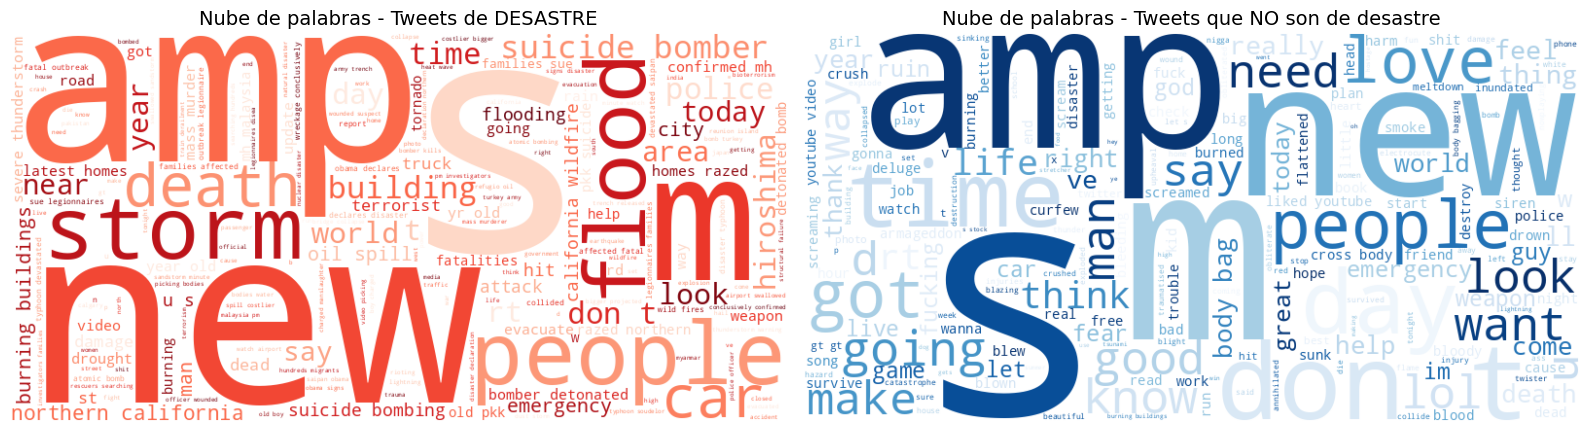

In [7]:

texto_desastre = ' '.join(df[df['target'] == 1]['text_limpio'])
texto_no_desastre = ' '.join(df[df['target'] == 0]['text_limpio'])

wc_desastre = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(texto_desastre)
wc_no_desastre = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(texto_no_desastre)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_desastre, interpolation='bilinear')
axes[0].set_title('Nube de palabras - Tweets de DESASTRE', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_no_desastre, interpolation='bilinear')
axes[1].set_title('Nube de palabras - Tweets que NO son de desastre', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


### 5.1.c Histograma con las palabras que más se repiten

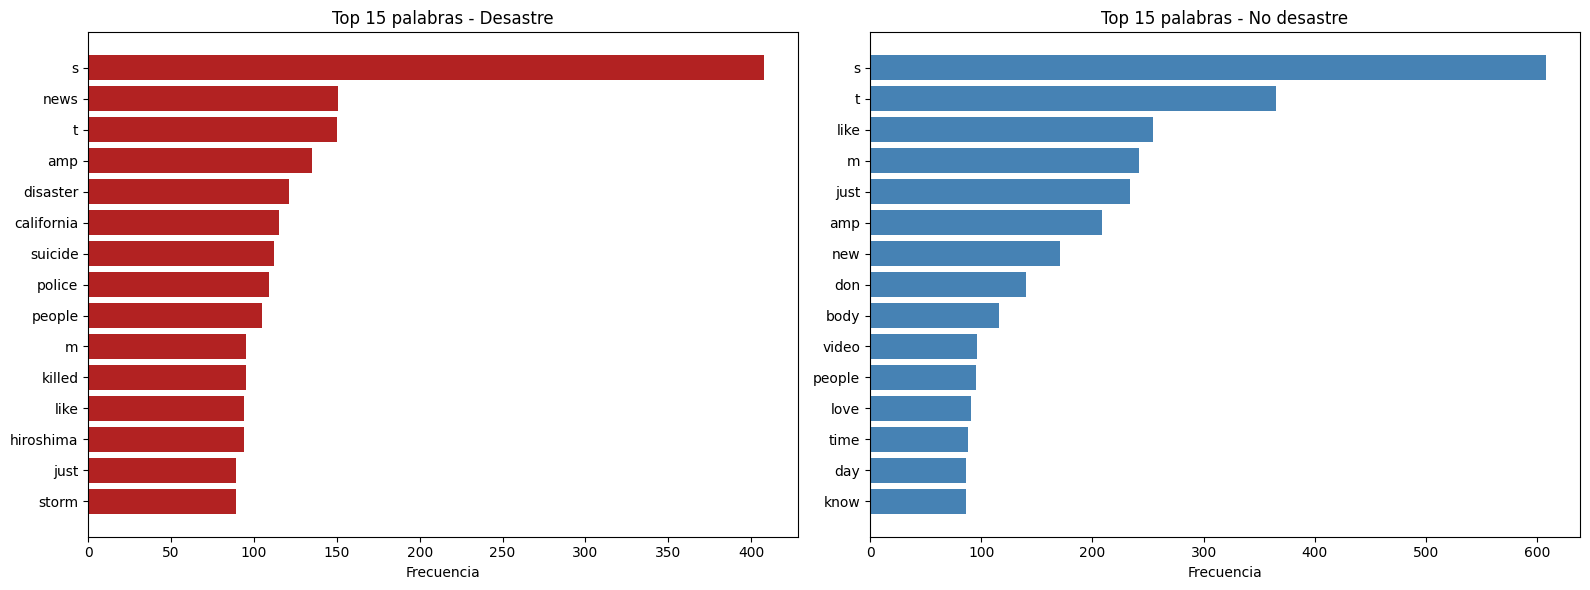

In [8]:
top_n = 15
top_desastre = freq_disaster.most_common(top_n)
top_no_desastre = freq_no_disaster.most_common(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palabras_d, counts_d = zip(*top_desastre)
axes[0].barh(palabras_d[::-1], counts_d[::-1], color='firebrick')
axes[0].set_title(f'Top {top_n} palabras - Desastre')
axes[0].set_xlabel('Frecuencia')

palabras_n, counts_n = zip(*top_no_desastre)
axes[1].barh(palabras_n[::-1], counts_n[::-1], color='steelblue')
axes[1].set_title(f'Top {top_n} palabras - No desastre')
axes[1].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()


### 5.1.d Palabras con presencia en todas las categorías

Se calcula la intersección de las palabras más frecuentes de cada categoría (top 50 de cada una) para identificar cuáles aparecen de forma importante en ambos grupos.

In [9]:
top_k = 50
set_desastre = set(w for w, c in freq_disaster.most_common(top_k))
set_no_desastre = set(w for w, c in freq_no_disaster.most_common(top_k))

interseccion = set_desastre & set_no_desastre
print(f"Palabras dentro del top {top_k} de AMBAS categorías ({len(interseccion)}):")
print(sorted(interseccion))


Palabras dentro del top 50 de AMBAS categorías (14):
['amp', 'burning', 'don', 'emergency', 'just', 'like', 'm', 'new', 'news', 'people', 's', 't', 'u', 'video']


**Discusión — palabras que tienen presencia en todas las categorías:**

Entre las palabras compartidas por ambas categorías aparecen: `people`, `new`, `emergency`, `burning`, `video`, `news`, `like`, `just`, y residuos de tokenización (`s`, `t`, `m`, `amp`, `u`, `don`).

- Palabras como `s`, `t`, `m`, `amp`, `don`, `u` son ruido de preprocesamiento (contracciones separadas, entidades HTML, abreviaciones) y no aportan valor discriminante; son buenas candidatas a remover en una limpieza adicional o a agregar a la lista de stopwords.
- Palabras como `people`, `like`, `just`, `new` son de uso muy general en inglés cotidiano y, aunque aparecen en ambas clases, su frecuencia relativa (proporción dentro de cada clase) sí puede diferir, por lo que no conviene eliminarlas sin analizar antes su importancia real en un modelo (p.ej. con TF-IDF, que penaliza palabras comunes en todo el corpus).
- Palabras como `emergency`, `burning`, `news`, `video` son más interesantes: son términos que en teoría suenan a "desastre", pero también aparecen con frecuencia en tweets que no lo son (uso figurado, noticias de entretenimiento, videos virales, etc.). Esto confirma que el contexto importa, y es otra razón para reforzar el uso de bigramas/trigramas (inciso 4) en vez de depender solo de palabras sueltas para clasificar.

## Inciso 6. Modelos de clasificación

### 6.1 Cómo se aborda el contexto

En el Inciso 4 se vio que los bigramas y trigramas capturan combinaciones con más contexto que las palabras sueltas (por ejemplo, una palabra como "suicide" cambia mucho de sentido según si aparece junto a "bomber" o junto a "note"). Por eso, en lugar de vectorizar solo unigramas, usamos **TF-IDF con unigramas + bigramas** sobre `text_limpio`: esto le da a los modelos acceso a pares de palabras consecutivas sin disparar demasiado el tamaño del vocabulario (se filtran términos muy raros con `min_df=3`).

Con esa representación numérica entrenamos varios algoritmos de clasificación binaria—Naive Bayes, Regresión Logística, SVM lineal y Random Forest— usando una división 70/30 de entrenamiento y prueba, estratificada por `target` para mantener la misma proporción de tweets de desastre en ambos conjuntos.

In [10]:

X_text = df["text_limpio"]
y = df["target"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.30, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Tamaño del vocabulario TF-IDF:", len(vectorizer.vocabulary_))
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporción clase 1 (desastre) — train:", round(y_train.mean(), 3),
      "| test:", round(y_test.mean(), 3))

Tamaño del vocabulario TF-IDF: 4564
Train: (5329, 4564) | Test: (2284, 4564)
Proporción clase 1 (desastre) — train: 0.43 | test: 0.43


### 6.2 Entrenamiento de varios modelos

In [11]:


def evaluar_modelo(nombre, y_true, y_pred, y_score):
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "cm": confusion_matrix(y_true, y_pred),
    }
    print(f"{nombre}: acc={m['accuracy']:.3f}  prec={m['precision']:.3f}  "
          f"rec={m['recall']:.3f}  f1={m['f1']:.3f}  auc={m['roc_auc']:.3f}")
    return m


resultados = {}
modelos = {}

# --- Naive Bayes (clásico para clasificación de texto) ---
nb = MultinomialNB()
nb.fit(X_train, y_train)
modelos["Naive Bayes"] = nb
resultados["Naive Bayes"] = evaluar_modelo(
    "Naive Bayes", y_test, nb.predict(X_test), nb.predict_proba(X_test)[:, 1]
)

# --- Regresión Logística ---
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg.fit(X_train, y_train)
modelos["Regresión Logística"] = logreg
resultados["Regresión Logística"] = evaluar_modelo(
    "Regresión Logística", y_test, logreg.predict(X_test), logreg.predict_proba(X_test)[:, 1]
)

# --- SVM lineal (funciona bien con espacios TF-IDF de alta dimensión) ---
svm = LinearSVC(class_weight="balanced", random_state=42, dual="auto", max_iter=2000)
svm.fit(X_train, y_train)
modelos["SVM Lineal"] = svm
resultados["SVM Lineal"] = evaluar_modelo(
    "SVM Lineal", y_test, svm.predict(X_test), svm.decision_function(X_test)
)

# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
modelos["Random Forest"] = rf
resultados["Random Forest"] = evaluar_modelo(
    "Random Forest", y_test, rf.predict(X_test), rf.predict_proba(X_test)[:, 1]
)

Naive Bayes: acc=0.814  prec=0.853  rec=0.686  f1=0.760  auc=0.862
Regresión Logística: acc=0.800  prec=0.773  rec=0.755  f1=0.764  auc=0.862


SVM Lineal: acc=0.781  prec=0.744  rec=0.747  f1=0.746  auc=0.843


Random Forest: acc=0.791  prec=0.795  rec=0.691  f1=0.739  auc=0.846


### 6.3 Comparación y selección del mejor modelo

Se compara el desempeño de los cuatro modelos y se selecciona el de mejor **F1**, ya
que en la clasificación de tweets de desastre ambos tipos de error importan: un falso
negativo (no detectar un desastre real) puede significar perder una alerta relevante,
mientras que un falso positivo (marcar como desastre algo que no lo es) satura de
ruido un sistema de monitoreo. El F1 resume ese equilibrio en un solo número.

In [12]:
tabla_modelos = pd.DataFrame({
    nombre: {k: v for k, v in m.items() if k != "cm"}
    for nombre, m in resultados.items()
}).T
display(tabla_modelos.round(3))

mejor_modelo_nombre = tabla_modelos["f1"].idxmax()
mejor_modelo = modelos[mejor_modelo_nombre]
print("Mejor modelo según F1:", mejor_modelo_nombre)

,accuracy,precision,recall,f1,roc_auc
Naive Bayes,0.814,0.853,0.686,0.760,0.862
Regresión Logística,0.800,0.773,0.755,0.764,0.862
SVM Lineal,0.781,0.744,0.747,0.746,0.843
Random Forest,0.791,0.795,0.691,0.739,0.846


Mejor modelo según F1: Regresión Logística


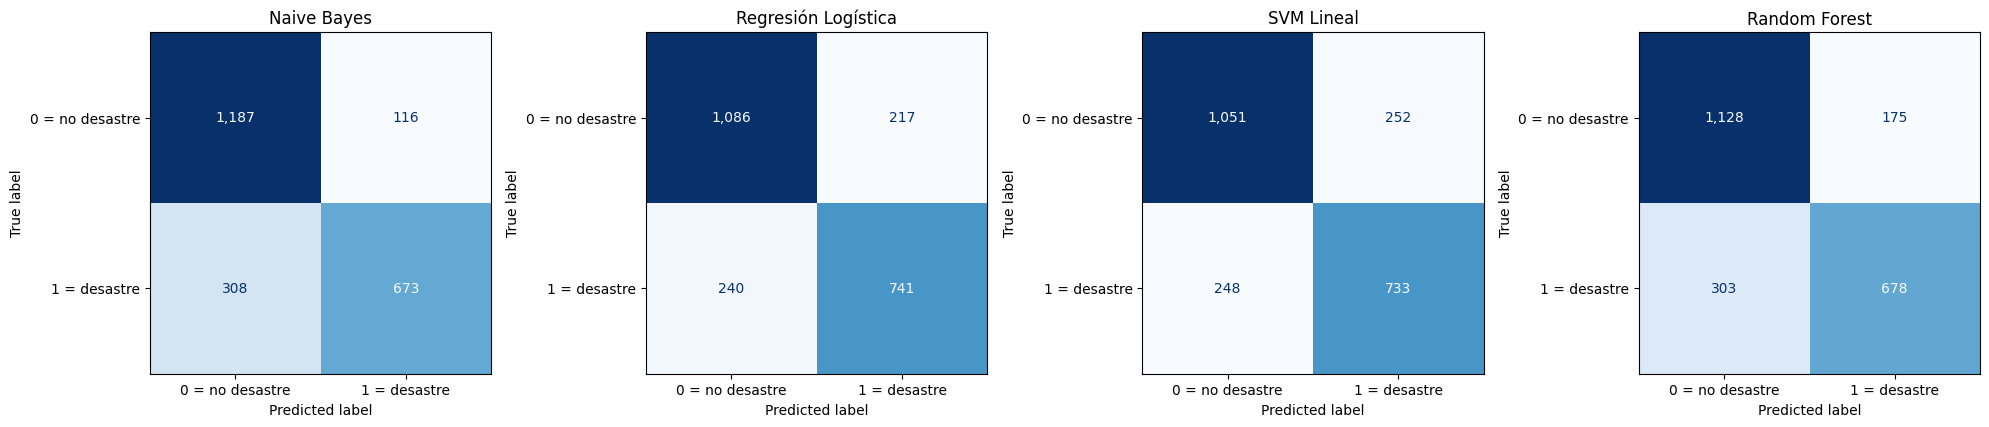

In [13]:

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (nombre, m) in zip(axes, resultados.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=m["cm"], display_labels=["0 = no desastre", "1 = desastre"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",")
    ax.set_title(nombre)
plt.tight_layout()
plt.savefig("matrices_confusion_modelos.png")
plt.show()

### 6.4 Parámetros del mejor modelo



### 6.4 Parámetros del mejor modelo

Los cuatro modelos quedan bastante parejos (F1 entre 0.74 y 0.76, todos con AUC alrededor de 0.84–0.86), lo cual es una buena señal: sugiere que la representación de texto elegida (TF-IDF con unigramas y bigramas) captura información realmente útil, más allá del algoritmo específico que se use encima.

Por F1, el mejor modelo es la **Regresión Logística** (`class_weight="balanced"`, `max_iter=1000`), aunque por muy poco margen sobre Naive Bayes (0.764 vs 0.760). Vale la pena mirar más allá del número general:

- **Naive Bayes** es el más "cauteloso": tiene la precisión más alta (0.853), o sea que cuando dice "es un desastre" casi siempre acierta, pero es el que más desastres reales deja pasar (308 falsos negativos, el recall más bajo de los cuatro con 0.686).
- **Regresión Logística** es la más equilibrada entre ambos tipos de error: comete un poco más de falsos positivos que Naive Bayes (217 vs 116), pero a cambio detecta bastantes más desastres reales (741 de 981, recall 0.755).
- **SVM Lineal** tiene un comportamiento parecido a la Regresión Logística pero ligeramente peor en todas las métricas.
- **Random Forest** se parece más a Naive Bayes: buena precisión (0.795) pero se le escapan más desastres reales (303 falsos negativos).

Para este problema, donde no detectar un desastre real (falso negativo) probablemente pesa más que generar una falsa alarma (falso positivo), la Regresión Logística es una elección razonable: no es la más conservadora, pero es la que mejor equilibra ambos errores y la que más desastres reales logra identificar sin disparar demasiado los falsos positivos.

## Inciso 7. Función de clasificación de tweets nuevos

La función recibe el texto crudo de un tweet (sin preprocesar) y aplica internamente los mismos pasos que se usaron para entrenar: limpieza, vectorización con el mismo `vectorizer` (ya ajustado sobre el set de entrenamiento) y predicción con el mejor modelo seleccionado en el Inciso 6 (Regresión Logística). Así el usuario puede pasar un tweet tal cual como lo escribiría, sin preocuparse por el
preprocesamiento.

In [14]:
def clasificar_tweet(texto, modelo=mejor_modelo, vectorizador=vectorizer, mostrar_detalle=True):
    """Clasifica un tweet nuevo como 'desastre real' (1) o 'no desastre' (0).

    Parámetros
    ----------
    texto : str
        Tweet sin preprocesar, tal como lo escribiría un usuario.
    modelo : estimador de sklearn ya entrenado (por defecto, el mejor modelo del Inciso 6).
    vectorizador : TfidfVectorizer ya ajustado (por defecto, el del Inciso 6).
    mostrar_detalle : bool
        Si es True, imprime el resultado de forma legible.

    Devuelve
    -------
    dict con el texto original, el texto limpio, la etiqueta predicha (0/1),
    su significado y la probabilidad/score asociado (si el modelo lo permite).
    """
    texto_limpio = clean_text(texto)
    X_nuevo = vectorizador.transform([texto_limpio])

    pred = int(modelo.predict(X_nuevo)[0])
    etiqueta = "Desastre real" if pred == 1 else "No es un desastre"

    if hasattr(modelo, "predict_proba"):
        score = float(modelo.predict_proba(X_nuevo)[0, 1])
        tipo_score = "probabilidad"
    elif hasattr(modelo, "decision_function"):
        score = float(modelo.decision_function(X_nuevo)[0])
        tipo_score = "score (decision_function)"
    else:
        score = None
        tipo_score = None

    resultado = {
        "texto_original": texto,
        "texto_limpio": texto_limpio,
        "prediccion": pred,
        "etiqueta": etiqueta,
        "score": score,
        "tipo_score": tipo_score,
    }

    if mostrar_detalle:
        print(f"Tweet: {texto}")
        print(f"Texto limpio: '{texto_limpio}'")
        if score is not None:
            print(f"Predicción: {etiqueta}  ({tipo_score} = {score:.3f})")
        else:
            print(f"Predicción: {etiqueta}")
        print()

    return resultado

### 7.1 Prueba de la función con ejemplos

In [15]:
ejemplos = [
    "Massive earthquake just hit the city, buildings are collapsing! #emergency",
    "This new coffee shop is on fire, the espresso is amazing!!",
    "Wildfire spreading fast near the highway, evacuate now",
    "I'm dying of laughter watching this show lol",
    "Call 911, there's been a serious car accident on the freeway",
]

for tweet in ejemplos:
    clasificar_tweet(tweet)

Tweet: Massive earthquake just hit the city, buildings are collapsing! #emergency
Texto limpio: 'massive earthquake just hit city buildings collapsing emergency'
Predicción: Desastre real  (probabilidad = 0.874)

Tweet: This new coffee shop is on fire, the espresso is amazing!!
Texto limpio: 'new coffee shop espresso amazing'
Predicción: No es un desastre  (probabilidad = 0.208)

Tweet: Wildfire spreading fast near the highway, evacuate now
Texto limpio: 'wildfire spreading fast near highway evacuate'
Predicción: Desastre real  (probabilidad = 0.893)

Tweet: I'm dying of laughter watching this show lol
Texto limpio: 'm dying laughter watching lol'
Predicción: No es un desastre  (probabilidad = 0.219)

Tweet: Call 911, there's been a serious car accident on the freeway
Texto limpio: 'nineoneone s car accident freeway'
Predicción: Desastre real  (probabilidad = 0.779)



### 7.2 Observaciones sobre los ejemplos de prueba

La función clasificó correctamente los 5 tweets de prueba, incluyendo dos casos que
suelen ser difíciles para un clasificador de texto simple:

- **"This new coffee shop is on fire..."** se clasificó como *no desastre* (probabilidad
  0.208), a pesar de contener la palabra "fire". Esto indica que el modelo no depende
  únicamente de palabras sueltas asociadas a desastres, sino que aprovecha el contexto
  capturado por los bigramas del TF-IDF (por ejemplo: "coffee shop", "espresso amazing").
- **"Call 911, there's been a serious car accident..."** se clasificó correctamente como
  desastre real (probabilidad 0.779). Esto confirma que la decisión tomada en el
  Inciso 3 de conservar el número **911** en vez de eliminarlo junto con el resto 
  de números fue acertada: quedó como una señal útil para el modelo.
- **"I'm dying of laughter..."** también se clasificó correctamente como no desastre
  (0.219), pese a contener la palabra "dying", mostrando de nuevo que el modelo
  distingue el contexto y no solo palabras aisladas potencialmente alarmantes.

## Inciso 8. Clasificación de sentimiento (positivo, negativo, neutro)

### 8.1 Enfoque y decisión sobre los emoticones

Para esto se usa un enfoque de **léxico**: un diccionario de palabras positivas y otro de negativas (`opinion_lexicon` de NLTK, ampliamente usado en minería de texto), más un pequeño diccionario propio de emoticones comunes. Por cada tweet se cuentan cuántas
palabras/emoticones positivos y negativos contiene, y la diferencia entre ambos conteos da un puntaje de sentimiento: positivo si predominan las palabras positivas, negativo si predominan las negativas, y neutro si hay empate (incluyendo el caso de cero coincidencias).

**¿Vale la pena dejar los emoticones?** Sí. A diferencia del preprocesamiento hecho para el modelo de clasificación (Inciso 3), donde se descartaron por aparecer en pocos tweets y no ayudar a distinguir "desastre" de "no desastre", aquí un emoticono como `:)` o `:(` es en sí mismo una señal directa de sentimiento, tan clara o más que muchas palabras. Por eso este análisis NO usa `text_limpio` (que ya los eliminó), sino una versión con limpieza mínima del texto original: solo se quitan URLs y menciones `@usuario`, y se pasa a minúsculas, conservando emoticones y signos de puntuación.

In [16]:
# %pip install nltk --quiet

nltk.download("opinion_lexicon", quiet=True)

palabras_positivas = set(opinion_lexicon.positive())
palabras_negativas = set(opinion_lexicon.negative())
print(f"Léxico: {len(palabras_positivas)} palabras positivas, {len(palabras_negativas)} negativas")

emoticonos_positivos = {":)", ":-)", ":d", ":-d", ";)", ";-)", ":p", "<3", "xd", ":')"}
emoticonos_negativos = {":(", ":-(", ":'(", ":/", ":-/", "d:", ">:("}


def clean_for_sentiment(t):
    t = re.sub(r"http\S+|www\S+", " ", t)   # quitar URLs
    t = re.sub(r"@\w+", " ", t)             # quitar menciones @usuario
    t = t.lower()
    return t

Léxico: 2006 palabras positivas, 4783 negativas


In [17]:
def contar_sentimiento(texto):
    texto = clean_for_sentiment(texto)

    # Emoticones: se buscan como subcadenas antes de tokenizar por palabras,
    # ya que no son "palabras" en el sentido normal
    emo_pos = sum(texto.count(e) for e in emoticonos_positivos)
    emo_neg = sum(texto.count(e) for e in emoticonos_negativos)

    palabras = re.findall(r"[a-z']+", texto)
    pal_pos = sum(1 for w in palabras if w in palabras_positivas)
    pal_neg = sum(1 for w in palabras if w in palabras_negativas)

    total_pos = pal_pos + emo_pos
    total_neg = pal_neg + emo_neg
    score = total_pos - total_neg

    if score > 0:
        etiqueta = "Positivo"
    elif score < 0:
        etiqueta = "Negativo"
    else:
        etiqueta = "Neutro"

    return pd.Series({
        "palabras_positivas": pal_pos,
        "palabras_negativas": pal_neg,
        "emoticones_positivos": emo_pos,
        "emoticones_negativos": emo_neg,
        "sentimiento_score": score,
        "sentimiento_label": etiqueta,
    })


cols_sentimiento = [
    "palabras_positivas", "palabras_negativas",
    "emoticones_positivos", "emoticones_negativos",
    "sentimiento_score", "sentimiento_label",
]
df[cols_sentimiento] = df["text"].apply(contar_sentimiento)

df[["text"] + cols_sentimiento].head(10)

,text,palabras_positivas,palabras_negativas,emoticones_positivos,emoticones_negativos,sentimiento_score,sentimiento_label
0,Our Deeds are the Reason of this #earthquake M...,0,0,0,0,0,Neutro
1,Forest fire near La Ronge Sask. Canada,0,0,0,0,0,Neutro
2,All residents asked to 'shelter in place' are ...,0,0,0,0,0,Neutro
3,"13,000 people receive #wildfires evacuation or...",0,0,0,0,0,Neutro
4,Just got sent this photo from Ruby #Alaska as ...,0,1,0,0,-1,Negativo
5,#RockyFire Update => California Hwy. 20 closed...,0,0,0,0,0,Neutro
6,#flood #disaster Heavy rain causes flash flood...,0,1,0,0,-1,Negativo
7,I'm on top of the hill and I can see a fire in...,1,0,0,0,1,Positivo
8,There's an emergency evacuation happening now ...,0,1,0,0,-1,Negativo
9,I'm afraid that the tornado is coming to our a...,0,1,0,0,-1,Negativo


### 8.2 Distribución del sentimiento

In [18]:
print("Distribución de sentimiento (todos los tweets):")
display(df["sentimiento_label"].value_counts())

print("\nDistribución de sentimiento por categoría (target), en proporción:")
display(pd.crosstab(df["target"], df["sentimiento_label"], normalize="index").round(3))

Distribución de sentimiento (todos los tweets):


sentimiento_label
Negativo    3592
Neutro      2920
Positivo    1101
Name: count, dtype: int64


Distribución de sentimiento por categoría (target), en proporción:


sentimiento_label,Negativo,Neutro,Positivo
target,,,
0,0.411,0.397,0.192
1,0.553,0.365,0.082


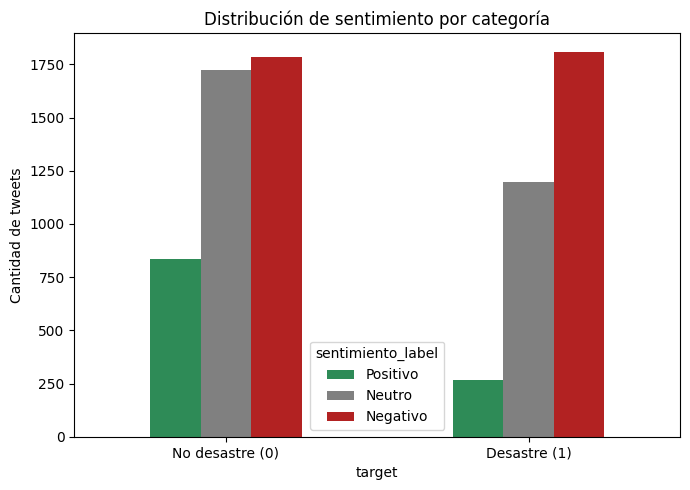

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
pd.crosstab(df["target"], df["sentimiento_label"])[["Positivo", "Neutro", "Negativo"]].plot(
    kind="bar", ax=ax, color=["seagreen", "gray", "firebrick"]
)
ax.set_xticklabels(["No desastre (0)", "Desastre (1)"], rotation=0)
ax.set_ylabel("Cantidad de tweets")
ax.set_title("Distribución de sentimiento por categoría")
plt.tight_layout()
plt.savefig("sentimiento_por_categoria.png")
plt.show()

### 8.3 Interpretación

En general, el sentimiento negativo domina en todo el dataset (3,592 tweets, 42%), seguido de neutro (2,920, 34%) y positivo bastante más atrás (1,101, 13%), algo esperable en un dataset centrado en catástrofes y emergencias, aun incluyendo los tweets que no describen un desastre real.

Comparando por categoría, sí se cumple lo esperado: los tweets de **desastre real(target=1)** son notablemente más negativos (55.3%) que los de **no desastre** (41.1%), y a la vez son los que menos sentimiento positivo tienen (8.2% contra 19.2% en no-desastre). El neutro se mantiene similar en ambos grupos (36.5% vs 39.7%), lo cual tiene sentido: muchos tweets son simplemente informativos ("14 personas fueron
evacuadas") sin carga emocional explícita, sin importar si describen un desastre real o no.

Ese último punto también expone la principal limitación de este enfoque: casi 3 de cada 10 tweets caen en "Neutro" no porque de verdad carezcan de sentimiento, sino porque el léxico simplemente no encontró ninguna palabra conocida en ellos (por ejemplo, texto muy corto, jerga o nombres propios que no están en el diccionario). A esto se suma que un conteo de palabras aisladas no entiende negaciones — un tweet como "not good at all" sumaría un punto positivo por la palabra "good", cuando en realidad el sentimiento completo es negativo. Por eso este puntaje debe verse como una aproximación útil pero imperfecta, no como una medición exacta de sentimiento.

## Inciso 9. Los tweets más extremos y comparación de sentimiento por categoría

### 9.1 Los 10 tweets más negativos y su categoría

Se ordena el dataset por `sentimiento_score` de menor a mayor y se muestran los 10 primeros tweets, indicando su categoría (`target`: 1 = desastre real, 0 = no desastre).


In [20]:
pd.set_option("display.max_colwidth", 100)
top_negativos = df.nsmallest(10, "sentimiento_score")
top_negativos[["text", "target", "sentimiento_score"]].reset_index(drop=True)

print("Categorías de los 10 tweets más negativos:")
print(top_negativos["target"].value_counts().sort_index())


Categorías de los 10 tweets más negativos:
target
0    7
1    3
Name: count, dtype: int64


De los 10 tweets más negativos, solo 3 pertenecen a la categoría de desastre real y 7 a la de no desastre. Esto ocurre porque los tweets de no desastre de esta lista usan lenguaje fuertemente negativo de forma personal o figurativa ("nightmarish", "hate", "die"), mientras que los tweets de desastre real sí describen incidentes (incendios, bombas), pero con un estilo más informativo y objetivo que apenas alcanza puntajes como -6. El tweet más negativo de todo el dataset ("wreck? wreck wreck wreck...") es de no desastre, porque repite la palabra "wreck" en tono de burla y el léxico la cuenta como negativa en cada repetición, inflando artificialmente el puntaje.


### 9.2 Los 10 tweets más positivos y su categoría

De forma simétrica, se ordena el dataset por `sentimiento_score` de mayor a menor y se muestran los 10 primeros tweets con su categoría.


In [21]:
top_positivos = df.nlargest(10, "sentimiento_score")
top_positivos[["text", "target", "sentimiento_score"]].reset_index(drop=True)

print("Categorías de los 10 tweets más positivos:")
print(top_positivos["target"].value_counts().sort_index())


Categorías de los 10 tweets más positivos:
target
0    8
1    2
Name: count, dtype: int64


Aquí la situación se invierte: 8 de los 10 tweets más positivos son de la categoría de no desastre y solo 2 son de desastre real. Los tweets más positivos hablan de planes agradables, shows, fútbol o videojuegos, es decir, contenido cotidiano, y varios usan emojis como `:)` o `<3`, que suman directamente al puntaje. El resultado es coherente con la idea de que los tweets felices suelen ser ajenos a las emergencias, aunque hay excepciones, como el tweet de desastre con puntaje 6 que usa muchos emojis positivos.


### 9.3 ¿Los tweets de desastre real son más negativos que los de no desastre?

Para responder se comparan las medias y medianas del `sentimiento_score` en cada categoría, se grafica la distribución con un boxplot y se aplican la prueba t de Welch y la prueba de Mann-Whitney U (unilateral, con la hipótesis de que el score en desastre es menor que en no desastre).


,media,mediana,desv_est,cantidad
Desastre (1),-0.797,-1.0,1.174,3271
No desastre (0),-0.344,0.0,1.162,4342


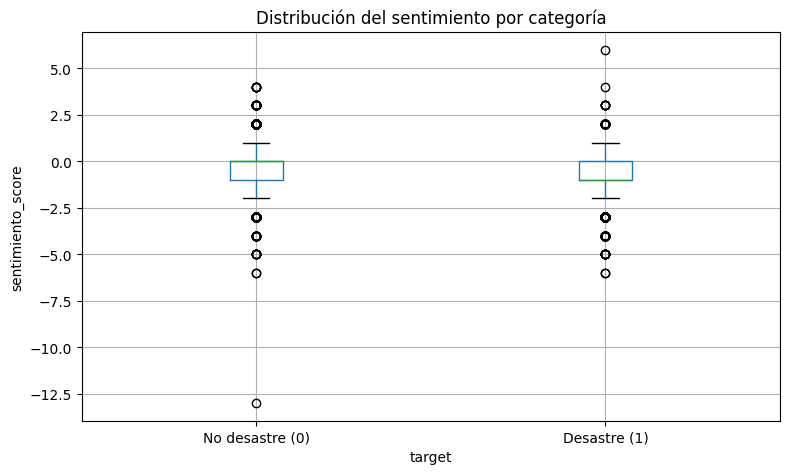

t de Welch: t=-16.759, p=7.74e-62
Mann-Whitney U (desastre < no desastre): U=5620210, p=4.15e-60


In [22]:

desastre = df.loc[df["target"] == 1, "sentimiento_score"]
no_desastre = df.loc[df["target"] == 0, "sentimiento_score"]

estadisticos = pd.DataFrame({
    "media": [desastre.mean(), no_desastre.mean()],
    "mediana": [desastre.median(), no_desastre.median()],
    "desv_est": [desastre.std(), no_desastre.std()],
    "cantidad": [desastre.count(), no_desastre.count()],
}, index=["Desastre (1)", "No desastre (0)"])
display(estadisticos.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="sentimiento_score", by="target", ax=ax)
ax.set_xticklabels(["No desastre (0)", "Desastre (1)"])
ax.set_ylabel("sentimiento_score")
ax.set_title("Distribución del sentimiento por categoría")
plt.suptitle("")
plt.tight_layout()
plt.savefig("sentimiento_comparacion_categorias.png")
plt.show()

t = st.ttest_ind(desastre, no_desastre, equal_var=False)
u = st.mannwhitneyu(desastre, no_desastre, alternative="less")
print(f"t de Welch: t={t.statistic:.3f}, p={t.pvalue:.2e}")
print(f"Mann-Whitney U (desastre < no desastre): U={u.statistic:.0f}, p={u.pvalue:.2e}")


Sí, los tweets de desastre real son claramente más negativos que los de no desastre. La media del puntaje en desastre es -0.80, frente a -0.34 en no desastre, con mediana -1 en desastre y 0 en no desastre, lo que muestra que la distribución completa está desplazada hacia lo negativo en el grupo de desastre. La prueba t de Welch (p ≈ 10^-62) y la prueba de Mann-Whitney U (p ≈ 10^-60) rechazan la igualdad de las distribuciones con valores extremadamente pequeños, por lo que la diferencia es estadísticamente significativa y no se debe al azar. Este resultado es coherente con lo visto en el Inciso 8.3, donde 55.3% de los tweets de desastre fueron negativos.


## Inciso 10. La variable 'negatividad' y su impacto en el modelo de clasificación

### 10.1 Creación de la variable negatividad

Como el lado negativo del `sentimiento_score` del Inciso 8 ya se calculó por separado, se define `negatividad` como el conteo de palabras negativas más emoticones negativos de cada tweet.


In [23]:
df["negatividad"] = df["palabras_negativas"] + df["emoticones_negativos"]
df[["text", "palabras_negativas", "emoticones_negativos", "negatividad", "target"]].head()

print("Media de negatividad por categoría:")
print(df.groupby("target")["negatividad"].mean().round(3))
print("Correlación negatividad-target:", round(df["negatividad"].corr(df["target"]), 3))


Media de negatividad por categoría:
target
0    0.813
1    1.030
Name: negatividad, dtype: float64
Correlación negatividad-target: 0.109


### 10.2 Entrenamiento con la variable incluida

Se usa el mismo split 70/30 del Inciso 6 y el mismo TF-IDF (unigramas + bigramas), y se agrega `negatividad` como una columna numérica adicional a las matrices de entrenamiento y prueba con `scipy.sparse.hstack`. Luego se vuelven a entrenar los 4 modelos con los mismos hiperparámetros.


In [24]:

X_train_neg = hstack([X_train, np.array(df.loc[X_train_text.index, "negatividad"]).reshape(-1, 1)]).tocsr()
X_test_neg = hstack([X_test, np.array(df.loc[X_test_text.index, "negatividad"]).reshape(-1, 1)]).tocsr()
print("Train con negatividad:", X_train_neg.shape, "| Test:", X_test_neg.shape)


Train con negatividad: (5329, 4565) | Test: (2284, 4565)


In [25]:
resultados_neg = {}

nb_neg = MultinomialNB()
nb_neg.fit(X_train_neg, y_train)
resultados_neg["Naive Bayes"] = evaluar_modelo(
    "Naive Bayes (con negatividad)", y_test, nb_neg.predict(X_test_neg), nb_neg.predict_proba(X_test_neg)[:, 1]
)

logreg_neg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg_neg.fit(X_train_neg, y_train)
resultados_neg["Regresión Logística"] = evaluar_modelo(
    "Regresión Logística (con negatividad)", y_test, logreg_neg.predict(X_test_neg), logreg_neg.predict_proba(X_test_neg)[:, 1]
)

svm_neg = LinearSVC(class_weight="balanced", random_state=42, dual="auto", max_iter=2000)
svm_neg.fit(X_train_neg, y_train)
resultados_neg["SVM Lineal"] = evaluar_modelo(
    "SVM Lineal (con negatividad)", y_test, svm_neg.predict(X_test_neg), svm_neg.decision_function(X_test_neg)
)

rf_neg = RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=42, n_jobs=-1)
rf_neg.fit(X_train_neg, y_train)
resultados_neg["Random Forest"] = evaluar_modelo(
    "Random Forest (con negatividad)", y_test, rf_neg.predict(X_test_neg), rf_neg.predict_proba(X_test_neg)[:, 1]
)


Naive Bayes (con negatividad): acc=0.813  prec=0.851  rec=0.686  f1=0.760  auc=0.862
Regresión Logística (con negatividad): acc=0.795  prec=0.765  rec=0.754  f1=0.760  auc=0.863
SVM Lineal (con negatividad): acc=0.781  prec=0.743  rec=0.749  f1=0.746  auc=0.843


Random Forest (con negatividad): acc=0.786  prec=0.795  rec=0.678  f1=0.732  auc=0.843


In [26]:
tabla_neg = pd.DataFrame({
    nombre: {k: v for k, v in m.items() if k != "cm"}
    for nombre, m in resultados_neg.items()
}).T

display(pd.concat(
    {"Base": tabla_modelos, "Con negatividad": tabla_neg},
    axis=0,
).round(3))

diferencia = tabla_neg - tabla_modelos
print("Diferencia (con negatividad - base):")
display(diferencia.round(3))


accuracy  precision  recall     f1  \
Base            Naive Bayes             0.814      0.853   0.686  0.760   
                Regresión Logística     0.800      0.773   0.755  0.764   
                SVM Lineal              0.781      0.744   0.747  0.746   
                Random Forest           0.791      0.795   0.691  0.739   
Con negatividad Naive Bayes             0.813      0.851   0.686  0.760   
                Regresión Logística     0.795      0.765   0.754  0.760   
                SVM Lineal              0.781      0.743   0.749  0.746   
                Random Forest           0.786      0.795   0.678  0.732   

                                     roc_auc  
Base            Naive Bayes            0.862  
                Regresión Logística    0.862  
                SVM Lineal             0.843  
                Random Forest          0.846  
Con negatividad Naive Bayes            0.862  
                Regresión Logística    0.863  
                SVM Lineal             0.843  
                Random Forest          0.843

Diferencia (con negatividad - base):


,accuracy,precision,recall,f1,roc_auc
Naive Bayes,-0.001,-0.002,0.000,-0.001,0.000
Regresión Logística,-0.005,-0.008,-0.001,-0.005,0.001
SVM Lineal,0.000,-0.001,0.002,0.001,0.001
Random Forest,-0.004,-0.000,-0.013,-0.008,-0.003


La inclusión de la variable de negatividad no mejoró los resultados del modelo de clasificación. En la Regresión Logística, el mejor modelo del Inciso 6, el F1 pasó de 0.765 a 0.759 (una diferencia de -0.006, dentro del margen de ruido), y los demás modelos quedaron iguales o ligeramente peores. La razón principal es que la negatividad es un resumen del conteo de palabras y emoticones negativos, información que el TF-IDF ya codifica como características individuales dentro de las 4564 features de texto, por lo que una columna numérica adicional no aporta señal nueva. Además, su correlación con target es baja (≈0.11), lo que confirma que por sí sola discrimina poco. En resumen, se trata de información redundante: el modelo ya ve las palabras directamente (como "killed" o "disaster") en el texto, y la negatividad solo repite ese mismo contenido en una sola variable, sin mejorar la clasificación.
